# Creating the KNN classifier

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

In [6]:
%store -r features
%store -r new_albums

In [8]:
data_dir = Path("data")
input_path = Path("..") / data_dir / "taylor_songs_no_TV.csv"

In [15]:
songs = pd.read_csv(input_path)
songs = songs.set_index(["name"])

In [76]:
songs['new_taylor'] = songs['album'].isin(new_albums)
%store songs

Stored 'songs' (DataFrame)


We are creating a new column called 'new_taylor' that indicates whether the album is new or not. This is our target column (y). The StandardScaler is used to scale all the variables.

In [18]:
X = songs[features].values
y = songs['new_taylor'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

songs_train, songs_test = train_test_split(songs, test_size=0.2, random_state=13)

X_train = songs_train[features].values
X_test = songs_test[features].values
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
y_train = songs_train['new_taylor'].values
y_test = songs_test['new_taylor'].values

For the KNN method we have to pick the K number of neighbours that has the highest accuracy. For now we will use a simpler method with just one train_test split to indicate the K.

In [44]:
neighbors = np.arange(1,21)
train_accuracies = {}
test_accuracies = {}
predictions = []

for neighbor in neighbors:
    knn = KNeighborsClassifier(n_neighbors=neighbor)
    knn.fit(X_train,y_train)
    train_accuracies[neighbor] = knn.score(X_train, y_train)
    test_accuracies[neighbor] = knn.score(X_test, y_test)

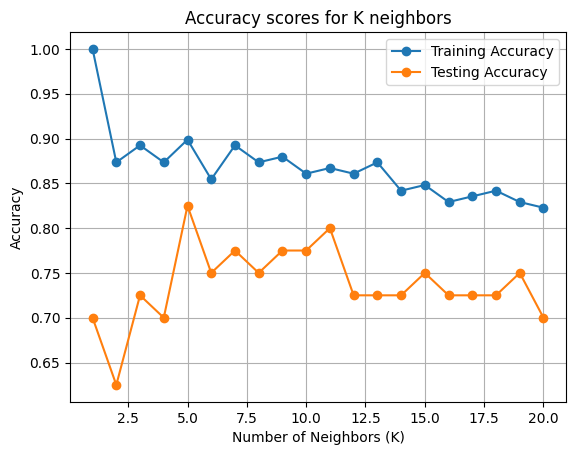

In [45]:
plt.plot(neighbors, train_accuracies.values(), label="Training Accuracy", marker="o", linestyle="-")
plt.plot(neighbors, test_accuracies.values(), label="Testing Accuracy", marker="o", linestyle="-")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("Accuracy scores for K neighbors")
plt.grid(True)
plt.legend()
plt.show()

We can see 2 peaks - at 5 and 11 neighbours. Testing accuracy never superseds the training accuracy. When changing the random state the peaks vary and the maximum accuracy depends on the randomness of the split. For more confirmation on which number to choose we will use CrossValidation that shuffles the splits multiple times to get more precise scores.

In [59]:
cv_scores_mean = []
cv_scores_std = []

for neighbor in neighbors:
    knn = KNeighborsClassifier(n_neighbors=neighbor)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring="accuracy")

    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

scores = {
    k: {"mean": mean, "std": std}
    for k, mean, std in zip(neighbors, cv_scores_mean, cv_scores_std)
}

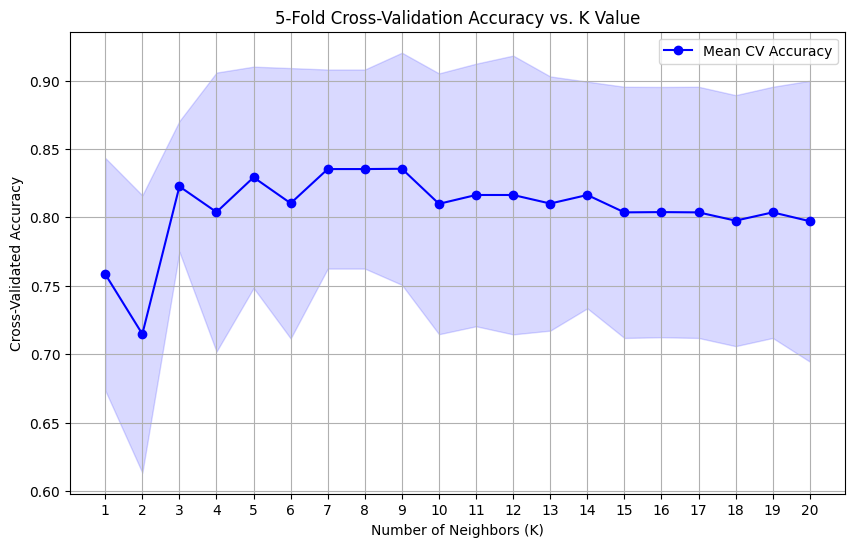

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(neighbors, cv_scores_mean, marker="o", linestyle="-", color="b", label="Mean CV Accuracy")

plt.fill_between(
    neighbors,
    np.array(cv_scores_mean) - np.array(cv_scores_std),
    np.array(cv_scores_mean) + np.array(cv_scores_std),
    alpha=0.15,
    color="b",
)

plt.title("5-Fold Cross-Validation Accuracy vs. K Value")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Cross-Validated Accuracy")
plt.xticks(neighbors)
plt.grid(True)
plt.legend()
plt.show()

We can see that after K=3, all the neighbours are somewhere between 0.8 and 0.85 with a few drops near the end of the graph. The best K is 9 with the mean score of around 0.83548. While the standard deviation is higher than for example K=7, the difference is not significant enough.

### Final model with K=9

In [66]:
knn2 = KNeighborsClassifier(n_neighbors=9)
knn2.fit(X_train, y_train)
y_pred = knn2.predict(X_test)

In [67]:
print(confusion_matrix(y_test, y_pred))

[[11  3]
 [ 6 20]]


Using the confusion matrix we can see that it assigned 11 True Positives, 20 True Negatives, 3 False Negatives and 6 False Positives.

In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.65      0.79      0.71        14
        True       0.87      0.77      0.82        26

    accuracy                           0.78        40
   macro avg       0.76      0.78      0.76        40
weighted avg       0.79      0.78      0.78        40



There is a slight dissproportion between the new era songs (118) and the old era songs (80), but with the average precision of 0.79, average recall of 0.78 the model is good enough to proceed.